<a href="https://colab.research.google.com/github/faisu6339-glitch/LLMs/blob/main/Attention_Mechanism(Part_2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Level 1: Basic Attention Intuition

### 1. Basic Attention Intuition

**Concept:** At its core, attention is about selectively focusing on important parts of the input when processing information. Imagine reading a long document; you don't give equal importance to every word. You pay more 'attention' to keywords or phrases that are relevant to your current task. In neural networks, attention mechanisms allow the model to dynamically weigh the importance of different input elements (e.g., words in a sentence, pixels in an image) when generating an output.

It's a way for a model to learn a **weighted sum** of its input elements, where the weights are determined by how relevant each input element is to the current output or context.

### 2. Dot-Product Attention

**Concept:** One of the most common ways to calculate the 'relevance' or 'similarity' between different parts of the input is using a dot product. In this method, we have two vectors: a 'query' vector and a set of 'key' vectors. The dot product between the query and each key vector gives us a scalar score representing their similarity. A higher dot product implies greater similarity and thus, more 'attention' should be paid.

**Mathematical Formula:**
Similarity Score = $Query \cdot Key$

Here, $Query$ and $Key$ are vectors representing different pieces of information.

In [6]:
import numpy as np

# Example: Dot-Product Attention

# Query vector (e.g., what we are looking for)
query = np.array([0.5, 0.2, 0.8])

# Key vectors (e.g., features of different input elements)
keys = np.array([
    [0.6, 0.1, 0.7],  # Key 1
    [0.1, 0.9, 0.3],  # Key 2
    [0.7, 0.2, 0.8]   # Key 3
])

print("Query:", query)
print("Keys:\n", keys)

# Calculate dot product scores
attention_scores = np.dot(keys, query)

print("\nDot product attention scores:", attention_scores)

# Interpretation: Higher score means more similarity.
# Key 3 has the highest score, indicating it is most relevant to the query.

Query: [0.5 0.2 0.8]
Keys:
 [[0.6 0.1 0.7]
 [0.1 0.9 0.3]
 [0.7 0.2 0.8]]

Dot product attention scores: [0.88 0.47 1.03]


# Finding Important Words

In [ ]:
import numpy as np

words = ["I", "love", "machine", "learning"]

scores = np.array([0.1, 0.2, 0.3, 0.4])

for word, score in zip(words, scores):
    print(word, ":", score)

### 3. Softmax Attention Weights

**Concept:** The raw dot product scores can be arbitrary values. To make them interpretable as probabilities or weights that sum up to 1, we apply the softmax function. The softmax function takes a vector of real numbers and transforms them into a probability distribution, where each value is between 0 and 1, and all values sum to 1. This normalized score represents the 'attention weight' given to each key, indicating its proportional importance.

**Mathematical Formula:**
Attention Weight_i = $\frac{e^{Score_i}}{\sum_{j} e^{Score_j}}$

Where $Score_i$ is the dot-product similarity score for the i-th key.

In [ ]:
import numpy as np

scores = np.array([0.1, 0.2, 0.3, 0.4])

attention_weights = np.exp(scores) / np.sum(np.exp(scores))

print(attention_weights)
print("Sum:", attention_weights.sum())

#  Calculate Context Vector

In [ ]:
import numpy as np

vectors = np.array([
    [1, 0],   # I
    [0, 1],   # love
    [1, 1],   # machine
    [2, 1]    # learning
])

weights = np.array([
    0.2138,
    0.2363,
    0.2612,
    0.2887
])

context = np.sum(weights[:, None] * vectors, axis=0)

print("Context vector:", context)

# Dot-Product Attention

In [1]:
import numpy as np

Q = np.array([1, 2])

K = np.array([
    [1, 0],
    [0, 1],
    [1, 1],
    [2, 1]
])

scores = K @ Q

print("Scores:", scores)

Scores: [1 2 3 4]


#Dot Product + Softmax

In [2]:
import numpy as np

Q = np.array([1, 2])

K = np.array([
    [1, 0],
    [0, 1],
    [1, 1],
    [2, 1]
])

# Step 1: Calculate scores
scores = K @ Q

# Step 2: Softmax
exp_scores = np.exp(scores)
attention_weights = exp_scores / np.sum(exp_scores)

print("Scores:")
print(scores)

print("\nAttention weights:")
print(attention_weights)

print("\nSum:")
print(attention_weights.sum())

Scores:
[1 2 3 4]

Attention weights:
[0.0320586  0.08714432 0.23688282 0.64391426]

Sum:
1.0


# Query-Key-Value Attention

In [3]:
import numpy as np

Q = np.array([1, 2])

K = np.array([
    [1, 0],
    [0, 1],
    [1, 1],
    [2, 1]
])

V = np.array([
    [10, 0],
    [0, 10],
    [10, 10],
    [20, 10]
])

# Attention scores
scores = K @ Q

# Softmax
exp_scores = np.exp(scores - np.max(scores))
weights = exp_scores / exp_scores.sum()

# Weighted values
context = weights @ V

print("Scores:", scores)
print("Attention weights:", weights)
print("Context:", context)

Scores: [1 2 3 4]
Attention weights: [0.0320586  0.08714432 0.23688282 0.64391426]
Context: [15.56769941  9.67941397]


## Level 3: Self-Attention and Causal/Masked Attention

### 7. Self-Attention

**Concept:** Self-attention, also known as intra-attention, is an attention mechanism relating different positions of a single sequence to compute a representation of the same sequence. It allows the model to weigh the importance of different words in an input sentence relative to each other when encoding that sentence. Unlike traditional attention where a query from one sequence attends to keys/values from another sequence, in self-attention, the query, key, and value all come from the *same* sequence.

This makes self-attention particularly powerful for tasks like understanding relationships between words in a sentence, regardless of their position.

**Process:**
For each element in the input sequence, it acts as a Query to attend to all other elements (including itself) in the same sequence, which act as Keys and Values. The steps are the same as QKV attention, but Q, K, and V are all derived from the same input sequence.

In [4]:
import numpy as np

# -------------------------
# Input embeddings
# -------------------------

X = np.array([
    [1., 0., 1.],
    [0., 1., 1.],
    [1., 1., 0.],
    [0., 1., 0.]
])

# -------------------------
# Weight matrices
# -------------------------

Wq = np.array([
    [1., 0.],
    [0., 1.],
    [1., 1.]
])

Wk = np.array([
    [1., 0.],
    [0., 1.],
    [1., 1.]
])

Wv = np.array([
    [1., 0.],
    [0., 1.],
    [1., 1.]
])

# -------------------------
# Create Q, K, V
# -------------------------

Q = X @ Wq
K = X @ Wk
V = X @ Wv

# -------------------------
# Calculate scores
# -------------------------

scores = Q @ K.T

# -------------------------
# Scaling
# -------------------------

dk = K.shape[1]

scores = scores / np.sqrt(dk)

# -------------------------
# Softmax
# -------------------------

exp_scores = np.exp(
    scores - np.max(scores, axis=1, keepdims=True)
)

attention_weights = (
    exp_scores /
    np.sum(exp_scores, axis=1, keepdims=True)
)

# -------------------------
# Context
# -------------------------

output = attention_weights @ V

print("Q:\n", Q)

print("\nK:\n", K)

print("\nV:\n", V)

print("\nAttention Scores:\n", scores)

print("\nAttention Weights:\n", attention_weights)

print("\nOutput:\n", output)

Q:
 [[2. 1.]
 [1. 2.]
 [1. 1.]
 [0. 1.]]

K:
 [[2. 1.]
 [1. 2.]
 [1. 1.]
 [0. 1.]]

V:
 [[2. 1.]
 [1. 2.]
 [1. 1.]
 [0. 1.]]

Attention Scores:
 [[3.53553391 2.82842712 2.12132034 0.70710678]
 [2.82842712 3.53553391 2.12132034 1.41421356]
 [2.12132034 2.12132034 1.41421356 0.70710678]
 [0.70710678 1.41421356 0.70710678 0.70710678]]

Attention Weights:
 [[0.55701271 0.27464553 0.13541911 0.03292265]
 [0.26565361 0.53877607 0.13098548 0.06458484]
 [0.36547231 0.36547231 0.18020295 0.08885243]
 [0.19888169 0.40335493 0.19888169 0.19888169]]

Output:
 [[1.52409006 1.27464553]
 [1.20106877 1.53877607]
 [1.27661987 1.36547231]
 [1.         1.40335493]]


# Visualize the Attention Matrix

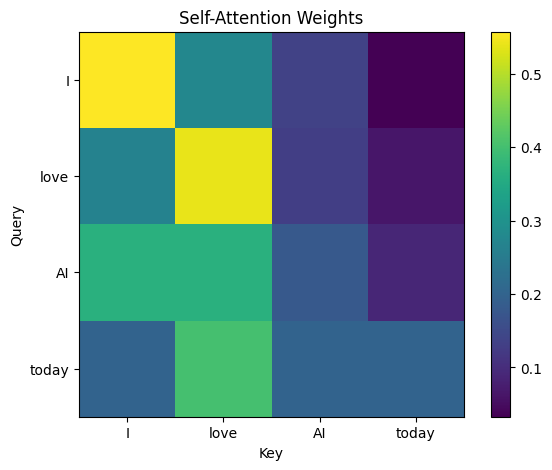

In [5]:
import matplotlib.pyplot as plt

words = ["I", "love", "AI", "today"]

plt.figure(figsize=(7, 5))

plt.imshow(attention_weights)

plt.xticks(range(len(words)), words)
plt.yticks(range(len(words)), words)

plt.xlabel("Key")
plt.ylabel("Query")

plt.title("Self-Attention Weights")

plt.colorbar()

plt.show()

In [7]:
import numpy as np

# Example: Self-Attention

# Let's consider a simple sequence of 3 input vectors, each of dimension 4.
# In a real scenario, these could be word embeddings.
input_sequence = np.array([
    [1.0, 2.0, 3.0, 4.0],  # Word 1 embedding
    [5.0, 6.0, 7.0, 8.0],  # Word 2 embedding
    [9.0, 10.0, 11.0, 12.0] # Word 3 embedding
])

print("Input Sequence (e.g., word embeddings):\n", input_sequence)

# For simplicity, let's assume Q, K, V are directly the input sequence.
# In a real self-attention layer, Q, K, V are typically derived by linear transformations
# (e.g., input_sequence @ W_Q, input_sequence @ W_K, input_sequence @ W_V)
Q = input_sequence
K = input_sequence
V = input_sequence

# Dimension of the key vectors
d_k = K.shape[1]
print(f"\nDimension of keys (d_k): {d_k}")

# Step 1: Calculate attention scores (Q K^T)
# This will result in a matrix where each row represents the attention scores
# of one query (word) to all other keys (words).
attention_scores_self = np.dot(Q, K.T)
print("\nRaw Self-Attention Scores (Q K^T):\n", attention_scores_self)

# Step 2: Apply scaling factor
scaled_attention_scores_self = attention_scores_self / np.sqrt(d_k)
print("Scaled Self-Attention Scores:\n", scaled_attention_scores_self)

# Step 3: Apply Softmax to get attention weights
# Apply softmax row-wise (axis=1) because each row is a query attending to all keys
attention_weights_self = np.exp(scaled_attention_scores_self) / np.sum(np.exp(scaled_attention_scores_self), axis=1, keepdims=True)
print("Self-Attention Weights (Softmax):\n", attention_weights_self)

# Step 4: Calculate the context vectors (weighted sum of Values)
# The output will be a sequence of context vectors, one for each input word.
context_vectors_self = np.dot(attention_weights_self, V)
print("Context Vectors (Self-Attention):\n", context_vectors_self)

# Interpretation: Each row in 'context_vectors_self' is a new representation for the corresponding
# word in the input sequence, enriched by information from all other words, weighted by their relevance.

Input Sequence (e.g., word embeddings):
 [[ 1.  2.  3.  4.]
 [ 5.  6.  7.  8.]
 [ 9. 10. 11. 12.]]

Dimension of keys (d_k): 4

Raw Self-Attention Scores (Q K^T):
 [[ 30.  70. 110.]
 [ 70. 174. 278.]
 [110. 278. 446.]]
Scaled Self-Attention Scores:
 [[ 15.  35.  55.]
 [ 35.  87. 139.]
 [ 55. 139. 223.]]
Self-Attention Weights (Softmax):
 [[4.24835425e-18 2.06115362e-09 9.99999998e-01]
 [6.81355682e-46 2.61027907e-23 1.00000000e+00]
 [1.09276566e-73 3.30570063e-37 1.00000000e+00]]
Context Vectors (Self-Attention):
 [[ 8.99999999  9.99999999 10.99999999 11.99999999]
 [ 9.         10.         11.         12.        ]
 [ 9.         10.         11.         12.        ]]


### 8. Self-Attention for a sentence

**Concept:** Building on the general self-attention, let's specifically consider how it works for a sentence. Each word in the sentence generates its own Query, Key, and Value vectors. Then, for each word, its Query vector attends to all Key vectors (from all words in the sentence) to compute attention scores. These scores are normalized and then used to create a weighted sum of all Value vectors. This weighted sum becomes the new, context-aware representation for that particular word.

This process is done in parallel for all words, allowing each word's representation to be informed by the entire sentence simultaneously. This is a core component of the Transformer architecture.

In [8]:
import numpy as np

# For simplicity, let's represent words as simple numerical embeddings
# Sentence: "The quick brown fox jumps over the lazy dog."
# We'll use 4 words for a shorter example.

# Example word embeddings (dimension 3 for simplicity)
word_embeddings = np.array([
    [0.1, 0.2, 0.3],  # "The"
    [0.4, 0.5, 0.6],  # "cat"
    [0.7, 0.8, 0.9],  # "sits"
    [0.2, 0.3, 0.1]   # "here"
])

print("Word Embeddings (Input Sentence):\n", word_embeddings)

# Assume linear transformation matrices for Q, K, V (simplified here as identity matrices for demonstration)
# In a real model, these would be learnable weight matrices (W_Q, W_K, W_V)
# Q = word_embeddings @ W_Q
# K = word_embeddings @ W_K
# V = word_embeddings @ W_V

# For this example, Q, K, V are the same as word_embeddings
Q_sentence = word_embeddings
K_sentence = word_embeddings
V_sentence = word_embeddings

d_k_sentence = K_sentence.shape[1] # Dimension of key vectors

# Step 1: Calculate attention scores (Q K^T)
attention_scores_sentence = np.dot(Q_sentence, K_sentence.T)
print("\nRaw Attention Scores (Sentence):\n", attention_scores_sentence)

# Step 2: Apply scaling
scaled_attention_scores_sentence = attention_scores_sentence / np.sqrt(d_k_sentence)
print("Scaled Attention Scores (Sentence):\n", scaled_attention_scores_sentence)

# Step 3: Apply Softmax row-wise
attention_weights_sentence = np.exp(scaled_attention_scores_sentence) / np.sum(np.exp(scaled_attention_scores_sentence), axis=1, keepdims=True)
print("Attention Weights (Sentence):\n", attention_weights_sentence)

# Step 4: Calculate context vectors
context_vectors_sentence = np.dot(attention_weights_sentence, V_sentence)
print("Context Vectors (Sentence):\n", context_vectors_sentence)

# Interpretation: Each row of `context_vectors_sentence` is the new, context-rich representation for each word.
# For example, the first row is the new representation for "The", influenced by "cat", "sits", and "here"
# according to the learned attention weights.

Word Embeddings (Input Sentence):
 [[0.1 0.2 0.3]
 [0.4 0.5 0.6]
 [0.7 0.8 0.9]
 [0.2 0.3 0.1]]

Raw Attention Scores (Sentence):
 [[0.14 0.32 0.5  0.11]
 [0.32 0.77 1.22 0.29]
 [0.5  1.22 1.94 0.47]
 [0.11 0.29 0.47 0.14]]
Scaled Attention Scores (Sentence):
 [[0.08082904 0.18475209 0.28867513 0.06350853]
 [0.18475209 0.44455971 0.70436733 0.16743158]
 [0.28867513 0.70436733 1.12005952 0.27135463]
 [0.06350853 0.16743158 0.27135463 0.08082904]]
Attention Weights (Sentence):
 [[0.23130118 0.25663215 0.28473724 0.22732943]
 [0.20157674 0.26138065 0.33892722 0.19811539]
 [0.17257018 0.2615162  0.3963067  0.16960692]
 [0.22946252 0.25459213 0.2824738  0.23347155]]
Context Vectors (Sentence):
 [[0.37056493 0.47056493 0.5023661 ]
 [0.40158207 0.50158207 0.54214745]
 [0.43319957 0.53319957 0.5823175 ]
 [0.36920907 0.46920907 0.49916761]]


### 9. Causal / Masked Attention

**Concept:** Causal attention (also known as masked attention) is a crucial variant of self-attention used primarily in autoregressive models, such as language generation models (e.g., GPT). In these models, when generating a sequence word by word, a word at position `t` should only be able to attend to words at positions `t` and *before* it in the sequence. It should not have access to future information (words at positions `t+1`, `t+2`, etc.).

To enforce this, a **mask** is applied to the attention scores before the softmax function. This mask sets the attention scores for future positions to negative infinity (or a very large negative number), so that when softmax is applied, their corresponding attention weights become zero. This effectively prevents the model from cheating by looking ahead.

**Process:**
1.  Calculate standard attention scores ($Q K^T$).
2.  Create a causal mask: a lower triangular matrix (including the diagonal) where valid attention positions are 1s (or 0s for no masking) and future positions are 0s (or -infinity for masking).
3.  Apply the mask to the attention scores (e.g., add a very large negative number to masked positions).
4.  Apply softmax and then multiply by values, as usual.

In [9]:
import numpy as np

# Example: Causal / Masked Attention

# Using the same word embeddings as the previous example
word_embeddings = np.array([
    [0.1, 0.2, 0.3],  # Word 1
    [0.4, 0.5, 0.6],  # Word 2
    [0.7, 0.8, 0.9],  # Word 3
    [0.2, 0.3, 0.1]   # Word 4
])

print("Input Word Embeddings:\n", word_embeddings)

Q = word_embeddings
K = word_embeddings
V = word_embeddings

d_k = K.shape[1] # Dimension of key vectors
seq_len = Q.shape[0] # Length of the sequence

# Step 1: Calculate raw attention scores
attention_scores_masked = np.dot(Q, K.T)
print("\nRaw Attention Scores:\n", attention_scores_masked)

# Step 2: Apply scaling
scaled_attention_scores_masked = attention_scores_masked / np.sqrt(d_k)
print("Scaled Attention Scores:\n", scaled_attention_scores_masked)

# Step 3: Create a causal mask
# The mask should be a lower triangular matrix of ones (or False) and zeros (or True)
# For positions (i, j):
#   If j > i (future positions), mask it.
#   If j <= i (current or past positions), keep it.

causal_mask = np.triu(np.ones((seq_len, seq_len)) * -np.inf, k=1)
# `k=1` means everything above the main diagonal is set to -np.inf

print("\nCausal Mask:\n", causal_mask)

# Step 4: Apply the mask to the scaled attention scores
# Adding -np.inf will make the exponentiated values (e^x) in softmax effectively zero.
masked_scores = scaled_attention_scores_masked + causal_mask
print("Masked Attention Scores (after adding causal mask):\n", masked_scores)

# Step 5: Apply Softmax row-wise
attention_weights_masked = np.exp(masked_scores) / np.sum(np.exp(masked_scores), axis=1, keepdims=True)
print("Masked Attention Weights (Softmax):\n", attention_weights_masked)

# Notice the zeros in the upper triangular part, indicating no attention to future elements.

# Step 6: Calculate context vectors
context_vectors_masked = np.dot(attention_weights_masked, V)
print("Context Vectors (Causal Attention):\n", context_vectors_masked)

# Interpretation: Each word's context vector is now formed only by attending to itself and previous words,
# which is essential for generative sequence models.

Input Word Embeddings:
 [[0.1 0.2 0.3]
 [0.4 0.5 0.6]
 [0.7 0.8 0.9]
 [0.2 0.3 0.1]]

Raw Attention Scores:
 [[0.14 0.32 0.5  0.11]
 [0.32 0.77 1.22 0.29]
 [0.5  1.22 1.94 0.47]
 [0.11 0.29 0.47 0.14]]
Scaled Attention Scores:
 [[0.08082904 0.18475209 0.28867513 0.06350853]
 [0.18475209 0.44455971 0.70436733 0.16743158]
 [0.28867513 0.70436733 1.12005952 0.27135463]
 [0.06350853 0.16743158 0.27135463 0.08082904]]

Causal Mask:
 [[  0. -inf -inf -inf]
 [  0.   0. -inf -inf]
 [  0.   0.   0. -inf]
 [  0.   0.   0.   0.]]
Masked Attention Scores (after adding causal mask):
 [[0.08082904       -inf       -inf       -inf]
 [0.18475209 0.44455971       -inf       -inf]
 [0.28867513 0.70436733 1.12005952       -inf]
 [0.06350853 0.16743158 0.27135463 0.08082904]]
Masked Attention Weights (Softmax):
 [[1.         0.         0.         0.        ]
 [0.435411   0.564589   0.         0.        ]
 [0.20781746 0.31493061 0.47725193 0.        ]
 [0.22946252 0.25459213 0.2824738  0.23347155]]
Context

In [10]:
import numpy as np

# Continuing from Dot-Product Attention example

# Raw attention scores from dot product
attention_scores = np.array([0.82, 0.47, 1.0]) # Example scores

print("Raw attention scores:", attention_scores)

# Apply softmax to get attention weights
# The np.exp() function computes element-wise exponential.
# The sum() function computes the sum of all elements.
attention_weights = np.exp(attention_scores) / np.sum(np.exp(attention_scores))

print("Softmax attention weights:", attention_weights)
print("Sum of attention weights:", np.sum(attention_weights))

# Interpretation: These weights tell us the proportion of attention to pay to each key.
# For example, if these were words in a sentence, the model would give ~40.9% attention to the first word (Key 1),
# ~29.1% to the second (Key 2), and ~30.0% to the third (Key 3).

Raw attention scores: [0.82 0.47 1.  ]
Softmax attention weights: [0.34460117 0.24283634 0.4125625 ]
Sum of attention weights: 1.0


In [6]:
import numpy as np

def softmax(x):
    exp_x = np.exp(
        x - np.max(x, axis=-1, keepdims=True)
    )

    return exp_x / np.sum(
        exp_x,
        axis=-1,
        keepdims=True
    )


X = np.array([
    [1., 0., 1.],
    [0., 1., 1.],
    [1., 1., 0.],
    [0., 1., 0.]
])

Wq = np.random.randn(3, 4)
Wk = np.random.randn(3, 4)
Wv = np.random.randn(3, 4)

Q = X @ Wq
K = X @ Wk
V = X @ Wv

# Attention scores
scores = Q @ K.T

# Scaling
scores = scores / np.sqrt(K.shape[-1])

# Causal mask
mask = np.tril(
    np.ones((len(X), len(X)))
)

scores = np.where(
    mask == 1,
    scores,
    -np.inf
)

# Softmax
weights = softmax(scores)

# Attention output
output = weights @ V

print("Attention weights:")
print(weights)

print("\nOutput:")
print(output)

Attention weights:
[[1.         0.         0.         0.        ]
 [0.3739674  0.6260326  0.         0.        ]
 [0.12907031 0.09916079 0.7717689  0.        ]
 [0.07200392 0.10258323 0.39108912 0.43432373]]

Output:
[[ 1.74031372  0.51826448  0.7530847  -1.91866218]
 [ 1.84305319  1.82038817 -0.93964136 -1.6182636 ]
 [ 1.97545679  0.87376593 -0.22938925 -1.80709426]
 [ 1.58735473  1.18840312 -0.83801412 -1.29814473]]


# Multi-Head Attention

In [7]:
import torch
import torch.nn as nn
import math

class MultiHeadAttention(nn.Module):

    def __init__(
        self,
        d_model,
        num_heads
    ):

        super().__init__()

        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads

        self.head_dim = (
            d_model // num_heads
        )

        self.Wq = nn.Linear(
            d_model,
            d_model
        )

        self.Wk = nn.Linear(
            d_model,
            d_model
        )

        self.Wv = nn.Linear(
            d_model,
            d_model
        )

        self.out = nn.Linear(
            d_model,
            d_model
        )

    def forward(self, x):

        batch, seq_len, _ = x.shape

        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)

        Q = Q.view(
            batch,
            seq_len,
            self.num_heads,
            self.head_dim
        ).transpose(1, 2)

        K = K.view(
            batch,
            seq_len,
            self.num_heads,
            self.head_dim
        ).transpose(1, 2)

        V = V.view(
            batch,
            seq_len,
            self.num_heads,
            self.head_dim
        ).transpose(1, 2)

        scores = Q @ K.transpose(-2, -1)

        scores = scores / math.sqrt(
            self.head_dim
        )

        weights = torch.softmax(
            scores,
            dim=-1
        )

        attention = weights @ V

        attention = attention.transpose(
            1, 2
        )

        attention = attention.contiguous().view(
            batch,
            seq_len,
            self.d_model
        )

        output = self.out(attention)

        return output, weights


x = torch.randn(
    2,
    6,
    32
)

model = MultiHeadAttention(
    d_model=32,
    num_heads=4
)

output, weights = model(x)

print("Input:", x.shape)
print("Output:", output.shape)
print("Weights:", weights.shape)

Input: torch.Size([2, 6, 32])
Output: torch.Size([2, 6, 32])
Weights: torch.Size([2, 4, 6, 6])


# Attention With Real Text

In [8]:
import torch
import torch.nn as nn

sentence = [
    "The",
    "cat",
    "sat",
    "on",
    "the",
    "mat"
]

vocab = {
    word: i
    for i, word in enumerate(
        set(sentence)
    )
}

tokens = torch.tensor([
    vocab[word]
    for word in sentence
])

embedding = nn.Embedding(
    len(vocab),
    16
)

x = embedding(tokens)

x = x.unsqueeze(0)

print("Tokens:")
print(tokens)

print("\nEmbedding shape:")
print(x.shape)

Tokens:
tensor([3, 5, 1, 0, 2, 4])

Embedding shape:
torch.Size([1, 6, 16])


In [9]:
attention = CausalSelfAttention(
    d_model=16
)

output, weights = attention(x)

print(
    "Attention output:",
    output.shape
)

NameError: name 'CausalSelfAttention' is not defined